In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [9]:
df = pd.read_csv('/content/IMDB Dataset.csv', engine='python', on_bad_lines='skip')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['sentiment'].value_counts())

Dataset Shape: (34831, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Missing Values:
review       0
sentiment    0
dtype: int64

Class Distribution:
sentiment
negative    17426
positive    17405
Name: count, dtype: int64


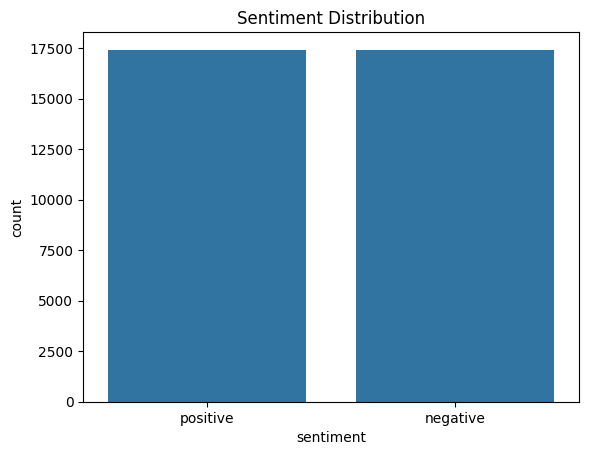

In [11]:
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

In [12]:
print("Sample Positive Review:\n")
print(df[df['sentiment'] == 'positive']['review'].iloc[0])

print("\n" + "="*100 + "\n")

print("Sample Negative Review:\n")
print(df[df['sentiment'] == 'negative']['review'].iloc[0])

Sample Positive Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of t

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [14]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = text.strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words and len(word) > 2:
            cleaned_tokens.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_tokens)

In [16]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Display cleaned text
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching episode youll ...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [18]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,1,one reviewer mentioned watching episode youll ...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [19]:
X = df['cleaned_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 27864
Testing Samples: 6967


In [20]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW Training Shape:", X_train_bow.shape)
print("BoW Testing Shape:", X_test_bow.shape)

BoW Training Shape: (27864, 5000)
BoW Testing Shape: (6967, 5000)


In [21]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (27864, 5000)
TF-IDF Testing Shape: (6967, 5000)


In [22]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{model_name} Performance")
    print("-" * 40)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    return accuracy, precision, recall, f1

In [23]:
lr_bow = LogisticRegression(max_iter=1000)

lr_bow_results = evaluate_model(
    lr_bow,
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "Logistic Regression with BoW"
)


Logistic Regression with BoW Performance
----------------------------------------
Accuracy : 0.8636
Precision: 0.8676
Recall   : 0.8581
F1 Score : 0.8628

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      3486
           1       0.87      0.86      0.86      3481

    accuracy                           0.86      6967
   macro avg       0.86      0.86      0.86      6967
weighted avg       0.86      0.86      0.86      6967



In [24]:
nb_bow = MultinomialNB()

nb_bow_results = evaluate_model(
    nb_bow,
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "Naive Bayes with BoW"
)
dt_bow = DecisionTreeClassifier(random_state=42)

dt_bow_results = evaluate_model(
    dt_bow,
    X_train_bow,
    X_test_bow,
    y_train,
    y_test,
    "Decision Tree with BoW"
)


Naive Bayes with BoW Performance
----------------------------------------
Accuracy : 0.8391
Precision: 0.843
Recall   : 0.8331
F1 Score : 0.838

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      3486
           1       0.84      0.83      0.84      3481

    accuracy                           0.84      6967
   macro avg       0.84      0.84      0.84      6967
weighted avg       0.84      0.84      0.84      6967


Decision Tree with BoW Performance
----------------------------------------
Accuracy : 0.7124
Precision: 0.7188
Recall   : 0.6969
F1 Score : 0.7077

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      3486
           1       0.72      0.70      0.71      3481

    accuracy                           0.71      6967
   macro avg       0.71      0.71      0.71      6967
weighted avg       0.71      0.71      0.71      6967



In [25]:
lr_tfidf = LogisticRegression(max_iter=1000)

lr_tfidf_results = evaluate_model(
    lr_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Logistic Regression with TF-IDF"
)


Logistic Regression with TF-IDF Performance
----------------------------------------
Accuracy : 0.8801
Precision: 0.8767
Recall   : 0.8845
F1 Score : 0.8806

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3486
           1       0.88      0.88      0.88      3481

    accuracy                           0.88      6967
   macro avg       0.88      0.88      0.88      6967
weighted avg       0.88      0.88      0.88      6967



In [26]:
nb_tfidf = MultinomialNB()

nb_tfidf_results = evaluate_model(
    nb_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Naive Bayes with TF-IDF"
)
dt_tfidf = DecisionTreeClassifier(random_state=42)

dt_tfidf_results = evaluate_model(
    dt_tfidf,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    "Decision Tree with TF-IDF"
)


Naive Bayes with TF-IDF Performance
----------------------------------------
Accuracy : 0.8458
Precision: 0.8428
Recall   : 0.85
F1 Score : 0.8464

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      3486
           1       0.84      0.85      0.85      3481

    accuracy                           0.85      6967
   macro avg       0.85      0.85      0.85      6967
weighted avg       0.85      0.85      0.85      6967


Decision Tree with TF-IDF Performance
----------------------------------------
Accuracy : 0.7112
Precision: 0.7175
Recall   : 0.6961
F1 Score : 0.7066

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.73      0.72      3486
           1       0.72      0.70      0.71      3481

    accuracy                           0.71      6967
   macro avg       0.71      0.71      0.71      6967
weighted avg       0.71      0.71      0.71      69

In [27]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression + BoW',
        'Naive Bayes + BoW',
        'Decision Tree + BoW',
        'Logistic Regression + TF-IDF',
        'Naive Bayes + TF-IDF',
        'Decision Tree + TF-IDF'
    ],
    'Accuracy': [
        lr_bow_results[0],
        nb_bow_results[0],
        dt_bow_results[0],
        lr_tfidf_results[0],
        nb_tfidf_results[0],
        dt_tfidf_results[0]
    ],
    'Precision': [
        lr_bow_results[1],
        nb_bow_results[1],
        dt_bow_results[1],
        lr_tfidf_results[1],
        nb_tfidf_results[1],
        dt_tfidf_results[1]
    ],
    'Recall': [
        lr_bow_results[2],
        nb_bow_results[2],
        dt_bow_results[2],
        lr_tfidf_results[2],
        nb_tfidf_results[2],
        dt_tfidf_results[2]
    ],
    'F1 Score': [
        lr_bow_results[3],
        nb_bow_results[3],
        dt_bow_results[3],
        lr_tfidf_results[3],
        nb_tfidf_results[3],
        dt_tfidf_results[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression + BoW,0.863643,0.867557,0.858087,0.862796
1,Naive Bayes + BoW,0.839099,0.843023,0.833094,0.838029
2,Decision Tree + BoW,0.712358,0.718815,0.696926,0.707701
3,Logistic Regression + TF-IDF,0.880149,0.876708,0.884516,0.880595
4,Naive Bayes + TF-IDF,0.845845,0.842780,0.850043,0.846396
5,Decision Tree + TF-IDF,0.711210,0.717501,0.696064,0.706620


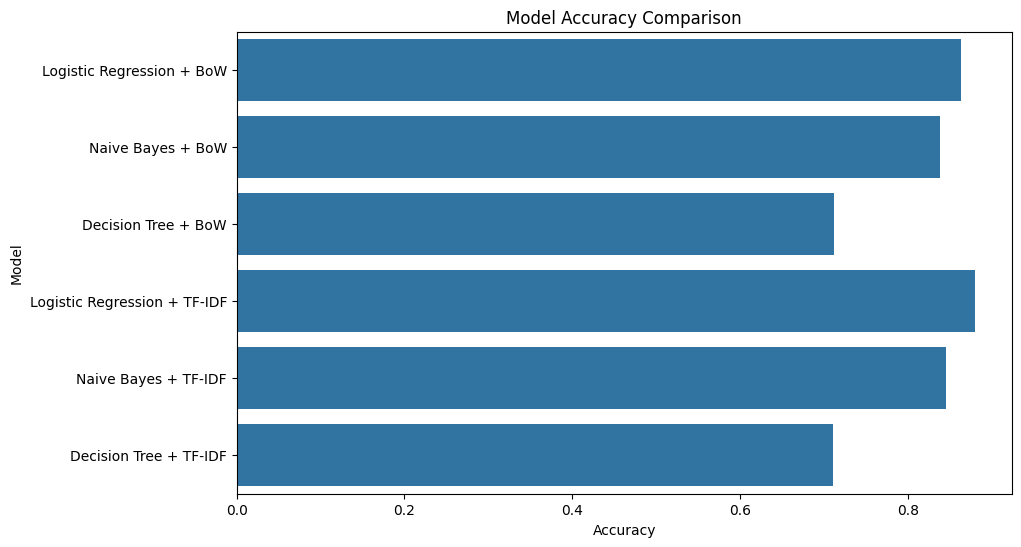

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results)
plt.title('Model Accuracy Comparison')
plt.show()

In [29]:
best_model = results.sort_values(by='Accuracy', ascending=False).iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression + TF-IDF
Accuracy                         0.880149
Precision                        0.876708
Recall                           0.884516
F1 Score                         0.880595
Name: 3, dtype: object


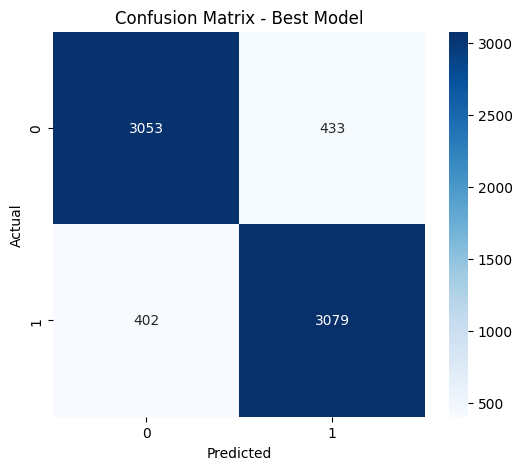

In [30]:
best_lr = LogisticRegression(max_iter=1000)
best_lr.fit(X_train_tfidf, y_train)

y_pred_best = best_lr.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()

In [31]:
print("Final Insights:")
print("""
1. Text preprocessing improved the quality of the data.
2. TF-IDF performed better than Bag of Words in most cases.
3. Logistic Regression gave the highest accuracy.
4. Naive Bayes was fast and performed well on text classification.
5. Decision Tree performed comparatively lower due to overfitting.
6. TF-IDF + Logistic Regression is the best combination for IMDb sentiment analysis.
""")

Final Insights:

1. Text preprocessing improved the quality of the data.
2. TF-IDF performed better than Bag of Words in most cases.
3. Logistic Regression gave the highest accuracy.
4. Naive Bayes was fast and performed well on text classification.
5. Decision Tree performed comparatively lower due to overfitting.
6. TF-IDF + Logistic Regression is the best combination for IMDb sentiment analysis.

